4/25
# This notebook contains code for Support Vector Regression
### for the COS475/575 Course Project

#### Code by Ben Caras and Roisin Rumsey
Sources:
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Access Dataset and extract data

In [2]:
df = pd.read_csv("AmesHousing.csv")

# Extract relevant columns
sqFeet = df[["Gr Liv Area"]].values
price = df["SalePrice"].values

### Plot data

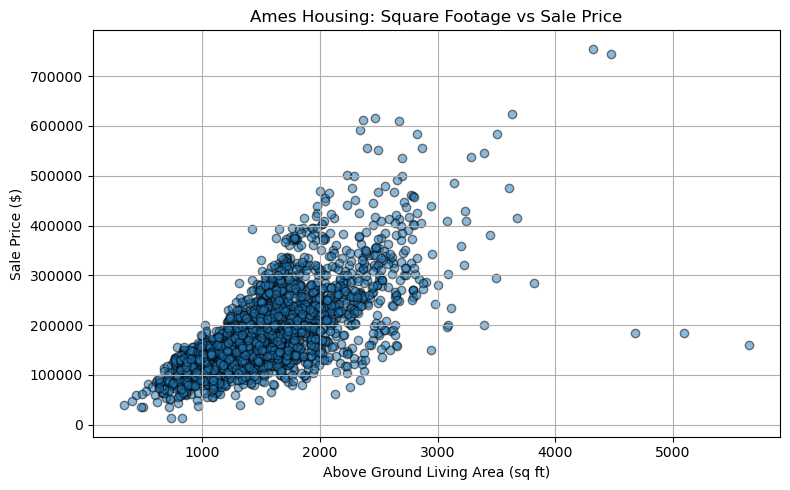

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(sqFeet, price, alpha=0.5, edgecolor='k')
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("Ames Housing: Square Footage vs Sale Price")
plt.grid(True)
plt.tight_layout()
plt.show()

### Linear Regression for Comparison

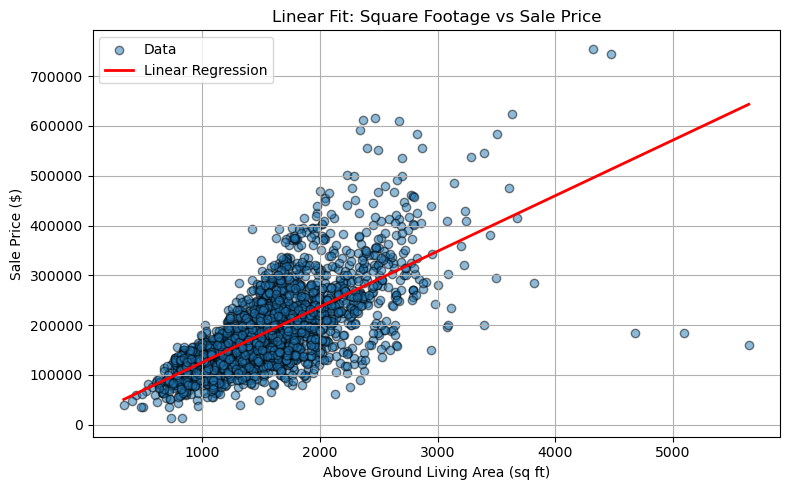

In [4]:
# Fit linear regression
model = LinearRegression()
model.fit(sqFeet, price)

# Predict on a range for a smooth line
x_range = np.linspace(sqFeet.min(), sqFeet.max(), 500).reshape(-1, 1)
y_pred = model.predict(x_range)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(sqFeet, price, alpha=0.5, edgecolor='k', label="Data")
plt.plot(x_range, y_pred, color="red", linewidth=2, label="Linear Regression")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("Linear Fit: Square Footage vs Sale Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SVR Implemetation

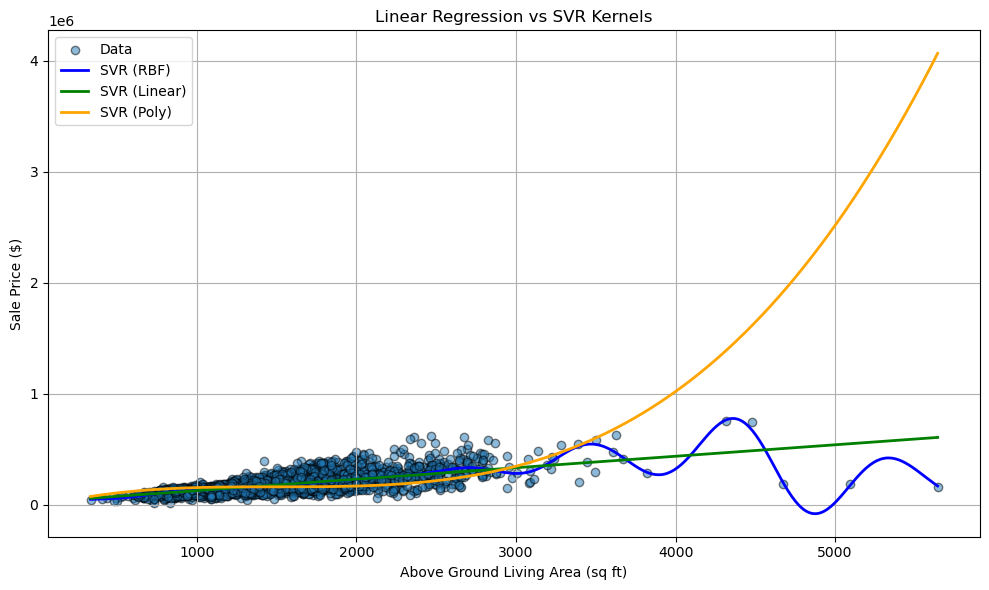

In [5]:
# Scale data for SVR
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(sqFeet)
y_scaled = y_scaler.fit_transform(price.reshape(-1, 1)).ravel()

# SVR models
svr_rbf = SVR(kernel='rbf', C=100, gamma=1)
svr_linear = SVR(kernel='linear', C=100)
svr_poly = SVR(kernel='poly', degree=3, C=.1)

# Predict using SVR and LinearRegression for comparison
x_range = np.linspace(sqFeet.min(), sqFeet.max(), 500).reshape(-1, 1)
x_range_scaled = x_scaler.transform(x_range)

y_svr_rbf_scaled = svr_rbf.fit(X_scaled, y_scaled).predict(x_range_scaled)
y_svr_rbf = y_scaler.inverse_transform(y_svr_rbf_scaled.reshape(-1, 1))

y_svr_linear_scaled = svr_linear.fit(X_scaled, y_scaled).predict(x_range_scaled)
y_svr_linear = y_scaler.inverse_transform(y_svr_linear_scaled.reshape(-1, 1))

y_svr_poly_scaled = svr_poly.fit(X_scaled, y_scaled).predict(x_range_scaled)
y_svr_poly = y_scaler.inverse_transform(y_svr_poly_scaled.reshape(-1, 1))

# Linear regression for reference
linreg = LinearRegression()
linreg.fit(sqFeet, price)
y_linreg = linreg.predict(x_range)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(sqFeet, price, alpha=0.5, edgecolor='k', label="Data")
plt.plot(x_range, y_svr_rbf, color="blue", label="SVR (RBF)", linewidth=2)
plt.plot(x_range, y_svr_linear, color="green", label="SVR (Linear)", linewidth=2)
plt.plot(x_range, y_svr_poly, color="orange", label="SVR (Poly)", linewidth=2)

plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("Linear Regression vs SVR Kernels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, price, test_size=0.2, random_state=42)

svr = SVR(kernel='rbf', C=2, gamma=0.1)
svr.fit(X_train, y_train)

preds = svr.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 8866078587.87


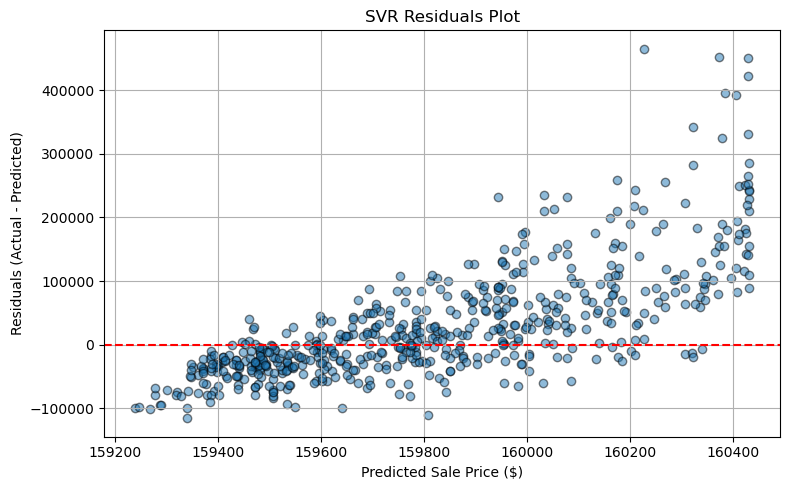

In [7]:
# Calculate residuals
residuals = y_test - preds

# Plot residuals
plt.figure(figsize=(8, 5))
plt.scatter(preds, residuals, alpha=0.5, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sale Price ($)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("SVR Residuals Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [100, 1000, 5000],
    'gamma': ['scale', 0.1, 1]
}
grid = GridSearchCV(SVR(kernel='poly'), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_scaled, price)

print("Best parameters:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

Best parameters: {'C': 0.1, 'epsilon': 5000, 'gamma': 'scale'}
Best CV MSE: 6635288670.719894
